In [207]:
import pandas as pd
import numpy as np

In [208]:
# data prep

In [209]:
data =  'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv'

In [210]:
!wget $data 

--2026-07-16 22:42:56--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.13’

data.csv.13         100%[===================>]   1.41M  --.-KB/s    in 0.03s   

2026-07-16 22:42:56 (49.1 MB/s) - ‘data.csv.13’ saved [1475504/1475504]



In [211]:
df = pd.read_csv('data.csv')

In [212]:
df.head()     # preview data (now cleaned)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [213]:
# clean column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [214]:
# example of what we are doing to each column in the for loop
df['make'].str.lower().str.replace(' ', '_')

0            bmw
1            bmw
2            bmw
3            bmw
4            bmw
          ...   
11909      acura
11910      acura
11911      acura
11912      acura
11913    lincoln
Name: make, Length: 11914, dtype: str

In [215]:
# now we will begin to clean values
strings = list(df.dtypes[df.dtypes == 'object'].index)           # gets all the columns with 'str' datatype into a list for the loop below
strings

[]

In [216]:
# loop to clean all the str values
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [217]:
df.head()      # clean!

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [218]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [219]:
# exploratory data analysis
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())


make
<StringArray>
['BMW', 'Audi', 'FIAT', 'Mercedes-Benz', 'Chrysler']
Length: 5, dtype: str
48
model
<StringArray>
['1 Series M', '1 Series', '100', '124 Spider', '190-Class']
Length: 5, dtype: str
915
year
[2011 2012 2013 1992 1993]
28
engine_fuel_type
<StringArray>
[   'premium unleaded (required)',               'regular unleaded',
 'premium unleaded (recommended)',       'flex-fuel (unleaded/E85)',
                         'diesel']
Length: 5, dtype: str
10
engine_hp
[335. 300. 230. 320. 172.]
356
engine_cylinders
[ 6.  4.  5.  8. 12.]
9
transmission_type
<StringArray>
['MANUAL', 'AUTOMATIC', 'AUTOMATED_MANUAL', 'DIRECT_DRIVE', 'UNKNOWN']
Length: 5, dtype: str
5
driven_wheels
<StringArray>
['rear wheel drive', 'front wheel drive', 'all wheel drive',
 'four wheel drive']
Length: 4, dtype: str
4
number_of_doors
[ 2.  4.  3. nan]
3
market_category
<StringArray>
['Factory Tuner,Luxury,High-Performance',
                    'Luxury,Performance',
               'Luxury,High-Performance

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

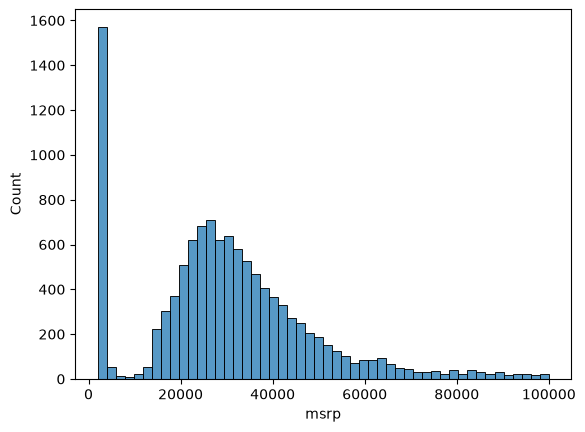

In [221]:
sns.histplot(df['msrp'][df['msrp'] < 100000], bins=50)

In [222]:
np.log1p([0, 1, 10, 1000, 10000])     # example of log1p

array([0.        , 0.69314718, 2.39789527, 6.90875478, 9.21044037])

In [223]:
price_logs = np.log1p(df.msrp)        

In [224]:
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

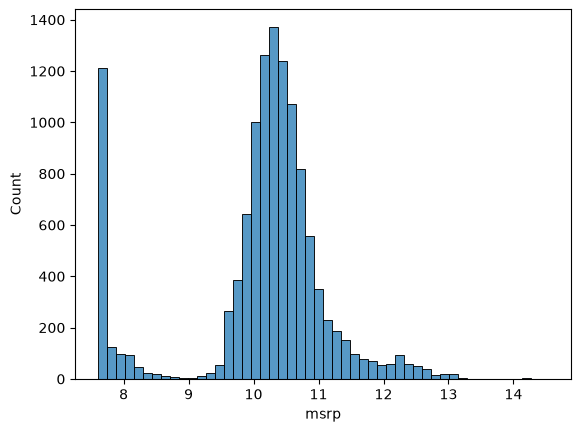

In [225]:
sns.histplot(price_logs, bins=50)

In [226]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [227]:
# setting up the validation framework

In [228]:
# splitting data into train, validation, and testing

n = len(df)

n_val = int(n * .2)

n_test = int(n * .2)

n_train = n - n_val - n_test

In [229]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [230]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_val+n_train]
df_test = df.iloc[n_val+n_train:]


In [231]:
# shuffle the values

idx = np.arange(n)

In [232]:

np.random.seed(2)
np.random.shuffle(idx)
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [233]:
df.iloc[idx[:10]]    # example of whats happening below

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,Chevrolet,Cobalt,2008,regular unleaded,148.0,4.0,MANUAL,front wheel drive,2.0,NaN,Compact,Coupe,33,24,1385,14410
6720,Toyota,Matrix,2012,regular unleaded,132.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,32,25,2031,19685
5878,Subaru,Impreza,2016,regular unleaded,148.0,4.0,AUTOMATIC,all wheel drive,4.0,Hatchback,Compact,4dr Hatchback,37,28,640,19795
11190,Volkswagen,Vanagon,1991,regular unleaded,90.0,4.0,MANUAL,rear wheel drive,3.0,NaN,Large,Passenger Minivan,18,16,873,2000
4554,Ford,F-150,2017,flex-fuel (unleaded/E85),385.0,8.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Crew Cab Pickup,21,15,5657,56260
8001,Volkswagen,Rabbit,2008,regular unleaded,170.0,5.0,MANUAL,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,29,22,873,17575
2882,Bentley,Continental GTC,2013,premium unleaded (required),500.0,8.0,AUTOMATIC,all wheel drive,2.0,"Exotic,Luxury,High-Performance",Midsize,Convertible,24,14,520,191400
649,BMW,6 Series,2015,premium unleaded (required),315.0,6.0,AUTOMATIC,rear wheel drive,2.0,"Luxury,Performance",Midsize,Coupe,32,21,3916,76100
616,Maybach,57,2012,premium unleaded (required),543.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury",Large,Sedan,16,10,67,379050
4459,Ford,F-150 Heritage,2004,regular unleaded,202.0,6.0,MANUAL,four wheel drive,2.0,NaN,Large,Regular Cab Pickup,18,13,5657,26030


In [234]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_val+n_train]]
df_test = df.iloc[idx[n_val+n_train:]]

In [235]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,Chevrolet,Cobalt,2008,regular unleaded,148.0,4.0,MANUAL,front wheel drive,2.0,NaN,Compact,Coupe,33,24,1385,14410
6720,Toyota,Matrix,2012,regular unleaded,132.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,32,25,2031,19685
5878,Subaru,Impreza,2016,regular unleaded,148.0,4.0,AUTOMATIC,all wheel drive,4.0,Hatchback,Compact,4dr Hatchback,37,28,640,19795
11190,Volkswagen,Vanagon,1991,regular unleaded,90.0,4.0,MANUAL,rear wheel drive,3.0,NaN,Large,Passenger Minivan,18,16,873,2000
4554,Ford,F-150,2017,flex-fuel (unleaded/E85),385.0,8.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Crew Cab Pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,BMW,4 Series,2015,premium unleaded (required),300.0,6.0,AUTOMATIC,rear wheel drive,2.0,"Luxury,Performance",Midsize,Convertible,31,20,3916,54900
1902,Volkswagen,Beetle,2015,premium unleaded (recommended),210.0,4.0,AUTOMATED_MANUAL,front wheel drive,2.0,"Hatchback,Performance",Compact,2dr Hatchback,30,24,873,29215
9334,GMC,Sierra 1500,2015,flex-fuel (unleaded/E85),285.0,6.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Extended Cab Pickup,22,17,549,34675
5284,Rolls-Royce,Ghost,2014,premium unleaded (required),563.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,Performance",Large,Sedan,21,13,86,303300


In [236]:
df_train.head()


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,Chevrolet,Cobalt,2008,regular unleaded,148.0,4.0,MANUAL,front wheel drive,2.0,NaN,Compact,Coupe,33,24,1385,14410
6720,Toyota,Matrix,2012,regular unleaded,132.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,32,25,2031,19685
5878,Subaru,Impreza,2016,regular unleaded,148.0,4.0,AUTOMATIC,all wheel drive,4.0,Hatchback,Compact,4dr Hatchback,37,28,640,19795
11190,Volkswagen,Vanagon,1991,regular unleaded,90.0,4.0,MANUAL,rear wheel drive,3.0,NaN,Large,Passenger Minivan,18,16,873,2000
4554,Ford,F-150,2017,flex-fuel (unleaded/E85),385.0,8.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Crew Cab Pickup,21,15,5657,56260


In [239]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,Chevrolet,Cobalt,2008,regular unleaded,148.0,4.0,MANUAL,front wheel drive,2.0,NaN,Compact,Coupe,33,24,1385,14410
6720,Toyota,Matrix,2012,regular unleaded,132.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,32,25,2031,19685
5878,Subaru,Impreza,2016,regular unleaded,148.0,4.0,AUTOMATIC,all wheel drive,4.0,Hatchback,Compact,4dr Hatchback,37,28,640,19795
11190,Volkswagen,Vanagon,1991,regular unleaded,90.0,4.0,MANUAL,rear wheel drive,3.0,NaN,Large,Passenger Minivan,18,16,873,2000
4554,Ford,F-150,2017,flex-fuel (unleaded/E85),385.0,8.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Crew Cab Pickup,21,15,5657,56260


In [240]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [242]:
# we dont need the original now shuffled indexies so we make it back into 0 - n-1

df_train.reset_index(drop=True)

df_val.reset_index(drop=True)

df_test.reset_index(drop=True)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,GMC,Vandura,1994,regular unleaded,165.0,6.0,AUTOMATIC,rear wheel drive,3.0,NaN,Compact,Cargo Van,20,15,549,2000
1,Mercedes-Benz,600-Class,1993,regular unleaded,389.0,12.0,AUTOMATIC,rear wheel drive,2.0,Luxury,Large,Coupe,15,11,617,3211
2,Toyota,Venza,2013,regular unleaded,268.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Performance",Midsize,Wagon,25,18,2031,31120
3,Volvo,740,1992,regular unleaded,114.0,4.0,AUTOMATIC,rear wheel drive,4.0,Luxury,Midsize,Sedan,26,18,870,2000
4,Ford,Crown Victoria,2010,flex-fuel (unleaded/E85),224.0,8.0,AUTOMATIC,rear wheel drive,4.0,Flex Fuel,Large,Sedan,24,16,5657,29905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,Chevrolet,Chevy Van,1998,regular unleaded,200.0,6.0,AUTOMATIC,rear wheel drive,3.0,NaN,Midsize,Cargo Van,18,13,1385,2052
2378,Subaru,XV Crosstrek,2014,regular unleaded,160.0,4.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hybrid",Compact,4dr SUV,33,29,640,25995
2379,Dodge,Magnum,2006,regular unleaded,250.0,6.0,AUTOMATIC,all wheel drive,4.0,NaN,Large,Wagon,22,15,1851,29100
2380,Honda,Civic,2016,regular unleaded,174.0,4.0,AUTOMATIC,front wheel drive,4.0,NaN,Midsize,Sedan,42,31,2202,22200


In [245]:
# get log1p vals of msrp (to eliminate the tail) (.values makes it into an array instead of a series)

y_train = np.log1p(df_train['msrp'].values)

y_val = np.log1p(df_val['msrp'].values)

y_test = np.log1p(df_test['msrp'].values)

In [246]:
# delete msrp (our target) from the features

del df_train['msrp']
del df_val['msrp']
del df_test['msrp']
